# <span style="color:#00bfff">Unidad 4. Inteligencia Artificial Moderna</span>

## <span style="color:#00bfff">Redes Neuronales Artificiales RNA (ANN)</span>

Ejemplo de ANN con Keras sobre el dataset Iris. 

1. Instalación de la librería Tensorflow

In [ ]:
%pip install tensorflow

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report
import numpy as np

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)
# 2. Escalamiento de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. One-hot encoding para etiquetas
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

# 4. División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42
)

# 5. Construcción del modelo ANN
model = Sequential(
    [
        Dense(
            10, activation="relu", input_shape=(X.shape[1],)
        ),  # 4 características de entrada
        Dense(8, activation="relu"),  # Capa oculta con 8 neuronas
        Dense(3, activation="softmax"),  # 3 clases
    ]
)

# 6. Compilar modelo
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# 7. Entrenar modelo
history = model.fit(X_train, y_train, epochs=100, batch_size=8, verbose=1)

# 8. Evaluar modelo
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en test: {acc:.3f}")

# 9. Predicciones y reporte
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print(
    "\nReporte de clasificación:\n",
    classification_report(y_true_labels, y_pred_labels, target_names=iris.target_names),
)

h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6190 - loss: 0.9193
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7238 - loss: 0.8668 
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7714 - loss: 0.8137 
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7905 - loss: 0.7619 
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - accuracy: 0.8095 - loss: 0.7131
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8286 - loss: 0.6683 
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8381 - loss: 0.6280 
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8286 - loss: 0.5927 
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8381 - loss: 0.5617 
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8381 - loss: 0.5355 
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8381 - loss: 0.5116
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step

Visualización del entrenamiento

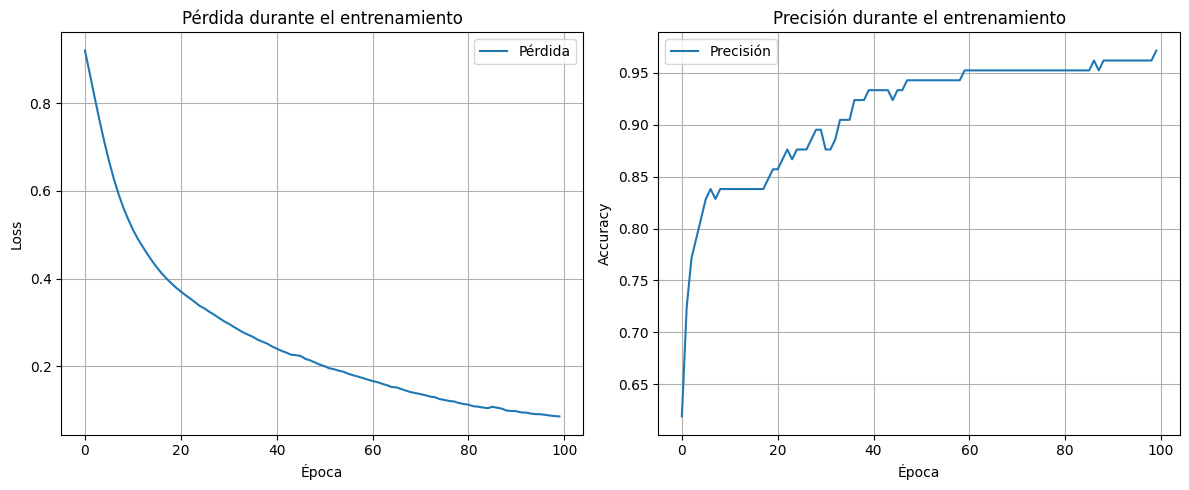

In [3]:
import matplotlib.pyplot as plt

# Visualizar evolución de la pérdida
plt.figure(figsize=(12, 5))

# Gráfico de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Gráfico de la precisión
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Precisión")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:#00bfff">Redes Neuronales Convolucionales - CNN</span>

A continuación, se construye y entrena una Red Neuronal Convolucional (CNN) con Keras usando el clásico dataset MNIST, que contiene imágenes en escala de grises de dígitos escritos a mano (0 al 9) en tamaño 28x28 píxeles.

1. Importación de librerías y carga de datos

In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Cargar dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar a [0,1] y expandir dimensiones (para CNN)
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0 
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# Codificar las etiquetas (one-hot)
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10) 

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


2. Previsualización de datos cargados

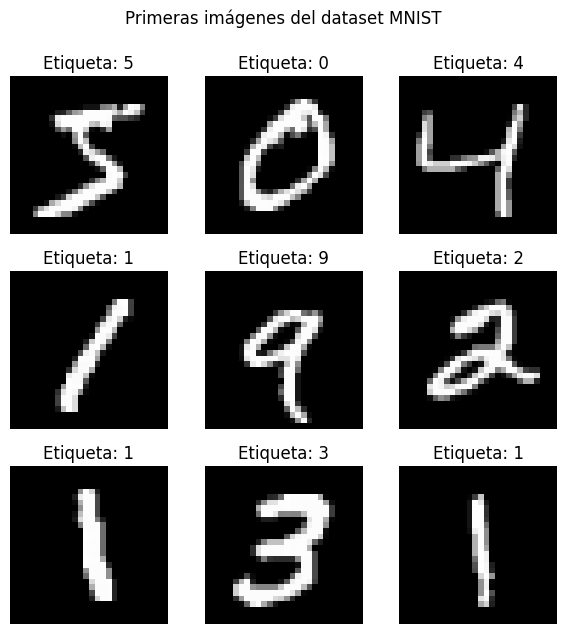

In [5]:
import matplotlib.pyplot as plt

# Mostrar las primeras 9 imágenes del conjunto de entrenamiento
plt.figure(figsize=(6, 6))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Primeras imágenes del dataset MNIST", y=1.05)
plt.show()

3. Construir el modelo CNN

In [6]:
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(), # Se aplana la salida de la última capa convolucional para conectarla a la capa densa
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Compilar y entrenar

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(X_train, y_train_cat, validation_split=0.1, epochs=5, batch_size=64) 

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9485 - loss: 0.1767 - val_accuracy: 0.9832 - val_loss: 0.0596
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9836 - loss: 0.0533 - val_accuracy: 0.9882 - val_loss: 0.0416
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9886 - loss: 0.0366 - val_accuracy: 0.9890 - val_loss: 0.0380
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9912 - loss: 0.0273 - val_accuracy: 0.9902 - val_loss: 0.0387
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9885 - val_loss: 0.0434


5. Evaluar y mostrar resultados

In [8]:
# Evaluación en test
loss, acc = model.evaluate(X_test, y_test_cat)
print(f"\nPrecisión en test: {acc:.4f}") 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9893 - loss: 0.0348

Precisión en test: 0.9893


6. Visualizar curvas de entrenamiento

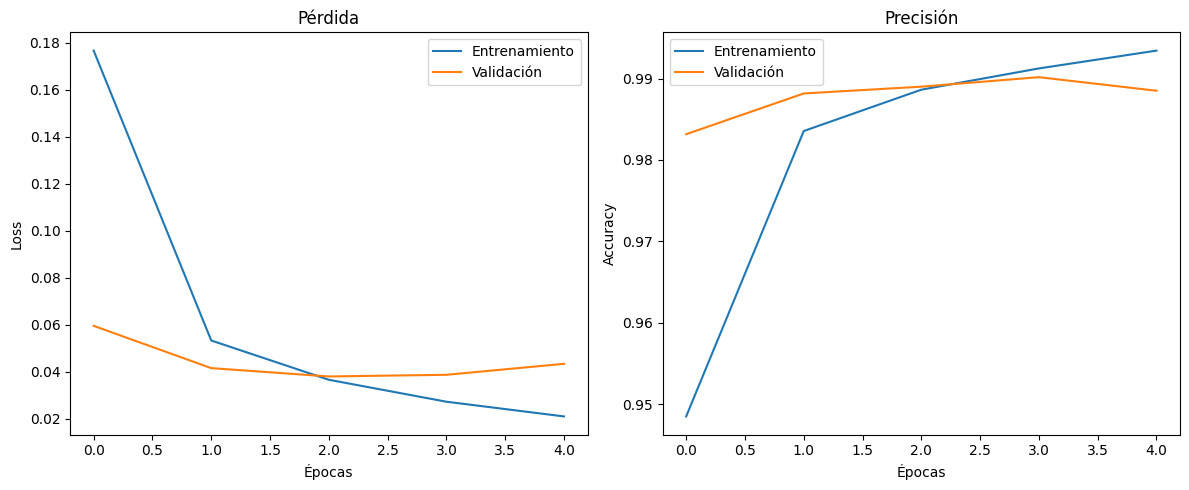

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Pérdida
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Precisión
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## <span style="color:#00bfff">Redes Neuronales Recurrentes - RNN</span>

1. Preparación de los datos

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Generar serie senoidal
x = np.linspace(0, 100, 500)
serie = np.sin(x)

# Escalar entre 0 y 1
scaler = MinMaxScaler()
serie_norm = scaler.fit_transform(serie.reshape(-1, 1))

# Crear ventanas de entrada/salida
def crear_ventanas(data, pasos=10):
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i+pasos])
        y.append(data[i+pasos])
    return np.array(X), np.array(y)

pasos = 20
X, y = crear_ventanas(serie_norm, pasos)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Requerido por LSTM

2. Construir y entrenar el modelo LSTM

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(50, activation='tanh', input_shape=(pasos, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=20, batch_size=16, verbose=1)

Epoch 1/20


h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1420   
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0452 
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0044
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7140e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6736e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5973e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1585e-04 
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2586e-05
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5365e-05
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0529e-05
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0332e-05 
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0597e-06 
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.6195e-06 
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4300e-06 
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2

3. Evaluar y visualizar resultados

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


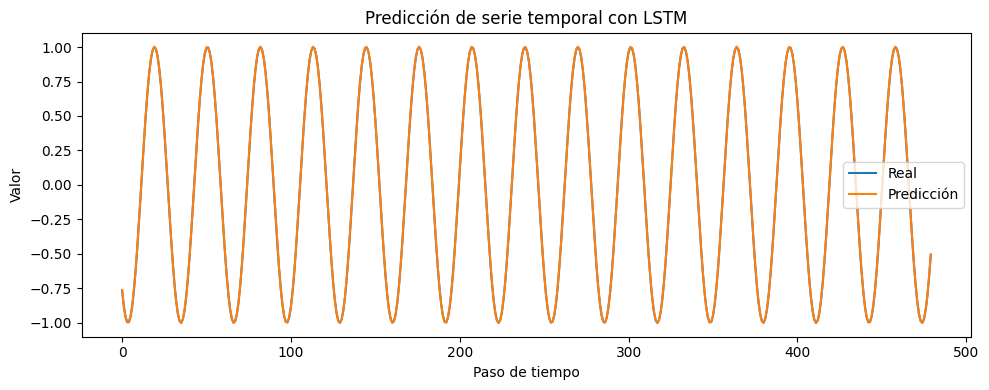

In [12]:
# Predecir con los mismos datos (ejemplo básico)
predicciones = model.predict(X)

# Invertir escalado
predicciones_inv = scaler.inverse_transform(predicciones)
y_real_inv = scaler.inverse_transform(y)

# Visualizar
plt.figure(figsize=(10,4))
plt.plot(y_real_inv, label='Real')
plt.plot(predicciones_inv, label='Predicción')
plt.title("Predicción de serie temporal con LSTM")
plt.xlabel("Paso de tiempo")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()

### <span style="color:#00bfff">Ejemplo de prediccíón de datos de texto con LSTM</span>

1. Preparación del corpus del texto

In [13]:
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Texto base (puede ser más largo)
texto = """la inteligencia artificial transforma el mundo de la tecnología y la ciencia. 
        La IA está revolucionando industrias enteras, desde la medicina hasta el entretenimiento. 
        Con algoritmos avanzados y grandes volúmenes de datos, las máquinas están aprendiendo a 
        realizar tareas complejas que antes eran exclusivas de los humanos. Sin embargo, también 
        plantea desafíos éticos y sociales que deben ser abordados con responsabilidad y cuidado. 
        La IA no es solo una herramienta, sino un cambio de paradigma en nuestra forma de 
        interactuar con el mundo."""

# Crear vocabulario
caracteres = sorted(list(set(texto)))
char2idx = {c: i for i, c in enumerate(caracteres)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(caracteres)

# Convertir texto en secuencia de índices
secuencia = [char2idx[c] for c in texto]

# Crear pares entrada-salida
X = []
y = []
seq_length = 50

for i in range(len(secuencia) - seq_length):
    X.append(secuencia[i : i + seq_length])
    y.append(secuencia[i + seq_length])

X = np.array(X)
y = to_categorical(y, num_classes=vocab_size)

# Redimensionar para LSTM
X = X.reshape((X.shape[0], X.shape[1], 1)) / float(vocab_size)

2. Crear y entrenar el modelo LSTM

In [14]:
model = Sequential([
    #LSTM(128, input_shape=(X.shape[1], X.shape[2])),
    LSTM(256, input_shape=(seq_length, 1), return_sequences=True),
    LSTM(128),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.fit(X, y, batch_size=16, epochs=100, verbose=0)

h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3. Generar texto a partir de una semilla

In [15]:
# Elegir una semilla
semilla = "la inteligencia artificial transforma el mundo de "
entrada = [char2idx[c] for c in semilla]

# Generar caracteres
generado = semilla

for _ in range(60):
    sec = np.array(entrada[-seq_length:]).reshape(1, seq_length, 1) / float(vocab_size)
    pred = model.predict(sec, verbose=0)
    index = np.argmax(pred)
    generado += idx2char[index]
    entrada.append(index)

print("Texto generado:\n", generado) 

Texto generado:
 la inteligencia artificial transforma el mundo de la tecnología y la ciencia. 
        La IA está revolucionan


## <span style="color:#00bfff">Transformers</span>

1. Instalación de HuggingFace Transformers

In [ ]:
%pip install transformers 

Note: you may need to restart the kernel to use updated packages.


h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Scripts\python.exe: No module named pip


Note: you may need to restart the kernel to use updated packages.


h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Scripts\python.exe: No module named pip


2. Cargar GPT-2 de HugginFace y generar texto. 

In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# 1. Cargar el modelo preentrenado y el tokenizer
modelo = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# 2. Frase inicial
semilla = "Artificial intelligence will transform the world in the following ways:"

# 3. Codificar entrada
input_ids = tokenizer.encode(semilla, return_tensors="pt")

# 4. Generar texto
output = modelo.generate(
    input_ids,
    max_length=100,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    temperature=0.6,
    top_k=50,
    top_p=0.95,
    do_sample=True
)

# 5. Decodificar y mostrar resultado
texto_generado = tokenizer.decode(output[0], skip_special_tokens=True)
print("\nTexto generado:\n")
print(texto_generado)

h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
h:\Mi unidad\Docencia\Inteligencia Artificial - Ing Sistemas\2025-2\IA-Course-UdB\Unidad 4\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jscely\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, y


Texto generado:

Artificial intelligence will transform the world in the following ways:

1. The first step is to create a system that learns how to use its own knowledge and use it in its best interest. This is the basic goal of AI.
, , and , are the first steps in this process. By the end of the year, AI will be able to learn to solve many of our problems. We already know that we can solve our own problems using the same methods we learned from previous generations
